<a href="https://colab.research.google.com/github/spencer18001/Practical-Deep-Learning/blob/main/note_score_based_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Score-Based Models

參考:
- Stanford CS236: Deep Generative Models I 2023
  - [Lecture 13 - Score Based Models
](https://www.youtube.com/watch?v=8G-OsDs1RLI&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=20)
  - [Lecture 14 - Energy Based Models
](https://www.youtube.com/watch?v=E69Lp_T9nVg&list=PLoROMvodv4rPOWA-omMM6STXaWW4FvJT8&index=14)
  - [Syllabus](https://deepgenerativemodels.github.io/syllabus.html)

#### Score-Based Model

*Definition* ***vector field***

$F(x)=\begin{bmatrix}
F_1(x)\\
\vdots\\
F_d(x)
\end{bmatrix};\ \mathbb{R}^d \to \mathbb{R}^d$

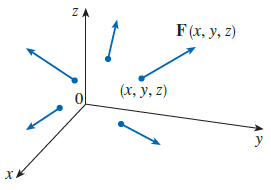

*Definition* ***gradient vector field***

$\nabla f(x)=\begin{bmatrix}
f_{x_1}(x)\\
\vdots\\
f_{x_d}(x)
\end{bmatrix};\ \mathbb{R}^d \to \mathbb{R}^d$

score function: $\nabla_x \log p(x)$
- gradient vector field: $\mathbb{R}^d \to \mathbb{R}^d$



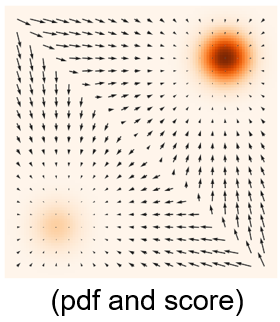

the score function is potentially much easier to work with

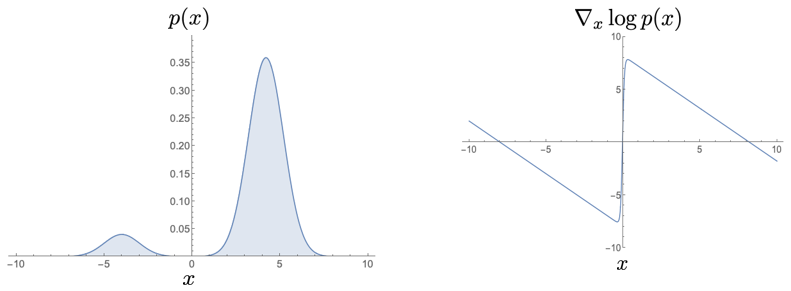

score-based model
- instead of modeling data using the density we're going to model data using the score
- $s_\theta(x): \mathbb{R}^d \to \mathbb{R}^d$

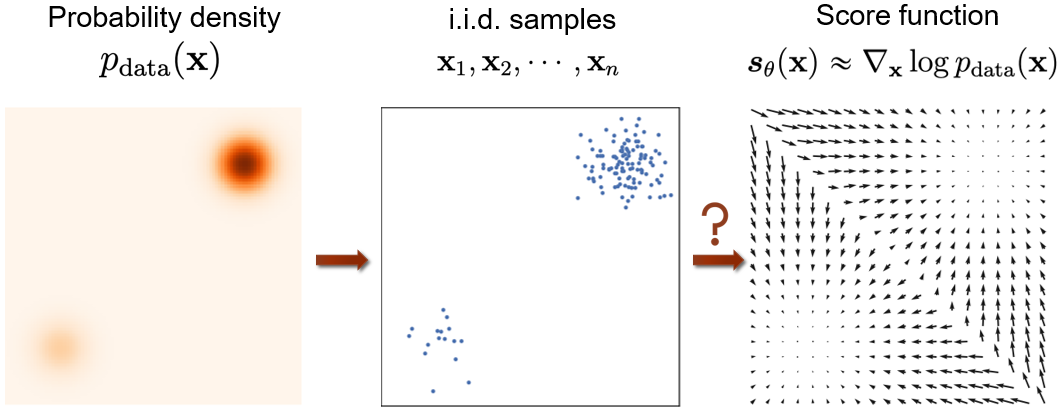

#### Score Matching

How to compare two vector fields of scores?

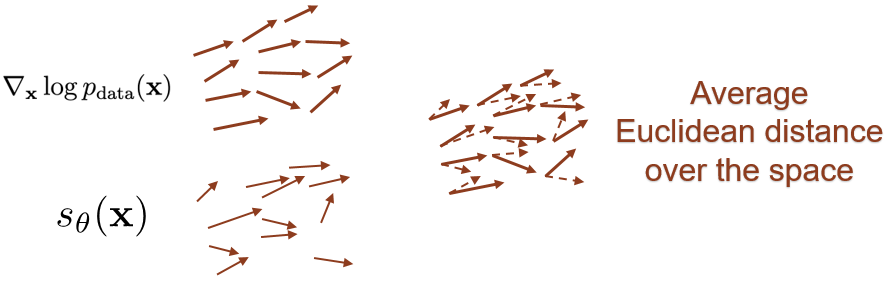

*Definition* ***Fisher divergence*** between $p(x)$ and $q(x)$

$D_F(p,q)=\frac{1}{2}\mathbb{E}_{x \sim p} \| \nabla_x \log p(x) - \nabla_x \log q(x) \|$

objective
- Fisher divergence: $\frac{1}{2}\mathbb{E}_{x \sim p_{\text{data}}} \| \nabla_x \log p_{\text{data}}(x) - s_\theta(x) \|_2^2$
- How to deal with $\nabla_x \log p_{\text{data}}(x)$ given only samples?

score matching
- $\mathbb{E}_{x \sim p_{\text{data}}} \left[ \frac{1}{2}\| s_\theta(x) \|_2^2 + \text{tr} \left( \nabla_x s_\theta(x) \right) \right]$
  - $\nabla_x s_\theta(x)$: Jacobian of $s_\theta(x)$

computing $\nabla_x s_\theta(x)$ is not scalable

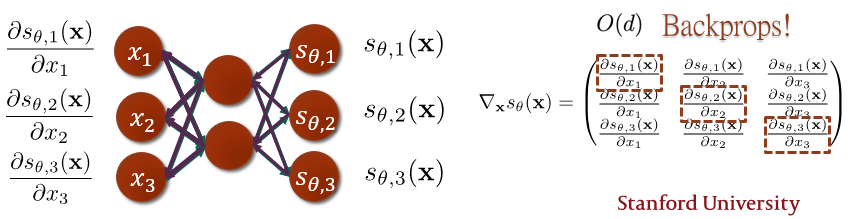

#### Denoising Score Matching

perturbed disttribution
- $q_\sigma(\tilde{x} \mid x)=\mathcal{N}(x;\sigma^2I)$
- $q_\sigma(\tilde{x})=\int p(x) q_\sigma(\tilde{x} \mid x) \text{d}x$

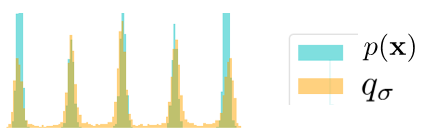

- Score estimation for $\nabla_{\tilde{x}} \log q_\sigma(\tilde{x})$ is easier
- If the noise level is small, this is a good approximation $q_\sigma(\tilde{x}) \approx p({\tilde{x}})$

*Norm squared identity*

$\| a-b \|_2^2=\| a \|_2^2+\| b \|_2^2-2a^Tb$

$\begin{align*}
&\quad\ \frac{1}{2}\mathbb{E}_{\tilde{x} \sim q_\sigma} \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \\
&= \frac{1}{2}\int q_\sigma(\tilde{x}) \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \text{d}\tilde{x} \\
&= \frac{1}{2}\int  q_\sigma(\tilde{x}) \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) \|_2^2 \text{d}\tilde{x}+\frac{1}{2}\int q_\sigma(\tilde{x}) \| s_\theta(\tilde{x}) \|_2^2 \text{d}\tilde{x}-\int q_\sigma(\tilde{x}) \nabla_\tilde{x} \log q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
\end{align*}$

$\begin{align*}
&\quad -\int q_\sigma(\tilde{x}) \nabla_\tilde{x} \log q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int q_\sigma(\tilde{x}) \frac{1}{q_\sigma(\tilde{x})} \nabla_\tilde{x} q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \nabla_\tilde{x} q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \nabla_\tilde{x} \left( \int p_{\text{data}}(x) q_\sigma(\tilde{x} \mid x)\text{d}x \right)^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \left( \int p_{\text{data}}(x) \nabla_\tilde{x} q_\sigma(\tilde{x} \mid x)\text{d}x \right)^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\int \left( \int p_{\text{data}}(x) q_\sigma(\tilde{x} \mid x) \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)\text{d}x \right)^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= -\iint p_{\text{data}}(x) q_\sigma(\tilde{x} \mid x) \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)^T s_\theta(\tilde{x}) \text{d}x \text{d}\tilde{x} \\
&= -\mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)^T s_\theta(\tilde{x}) \right]
\end{align*}$

*Iterated Expectation*

$\mathbb{E}_X(X)=\mathbb{E}_Y\left[ \mathbb{E}_{X \mid Y}(X \mid Y) \right]$

$\begin{align*}
&\quad\ \frac{1}{2}\mathbb{E}_{\tilde{x} \sim q_\sigma} \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \\
&= \text{const.} +\frac{1}{2}\int q_\sigma(\tilde{x}) \| s_\theta(\tilde{x}) \|_2^2 \text{d}\tilde{x}-\int q_\sigma(\tilde{x}) \nabla_\tilde{x} \log q_\sigma(\tilde{x})^T s_\theta(\tilde{x}) \text{d}\tilde{x} \\
&= \text{const.} +\frac{1}{2} \mathbb{E}_{\tilde{x} \sim q_\sigma} \left[ \| s_\theta(\tilde{x}) \|_2^2 \right]  -\mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)^T s_\theta(\tilde{x}) \right] \\
&= \text{const.} +\frac{1}{2} \mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \| s_\theta(\tilde{x})-\nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x) \|_2^2 \right]  -\frac{1}{2}\mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x) \right] \\
&= \frac{1}{2} \mathbb{E}_{x \sim p_{\text{data}}(x),\tilde{x} \sim q_\sigma(\tilde{x} \mid x)} \left[ \| s_\theta(\tilde{x})-\nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x) \|_2^2 \right] +\text{const.}
\end{align*}$

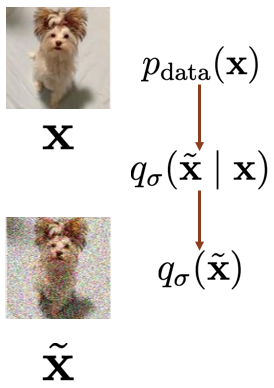

- $\nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)$ is easy to compute
  - $q_\sigma(\tilde{x} \mid x)=\mathcal{N}(x;\sigma^2I)$
  - $\displaystyle \nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)=-\frac{\tilde{x}-x}{\sigma^2}$
- $\begin{align*}
&\quad\ \frac{1}{2}\mathbb{E}_{\tilde{x} \sim q_\sigma} \| \nabla_\tilde{x} \log q_\sigma(\tilde{x}) - s_\theta(\tilde{x}) \|_2^2 \\
&=\displaystyle \frac{1}{2} \mathbb{E}_{x \sim p_{\text{data}}(x),z \sim \mathcal{N}(0,I)} \left[ \| s_\theta(x+\sigma z)+\frac{z}{\sigma} \|_2^2 \right] +\text{const.}
\end{align*}$
- Pros:
  - Much more scalable than score matching
  - Reduces score estimation to a denoising task
    - if you know how to denoise then you know how in which direction perturbing your image would increase the likelihood most rapidly
- Con: estimates score of noise-perturbed data

- Need to choose a very small $\sigma$!
- The loss variance will increase drastically as $\sigma \to 0$!

*Tweedie’s formula*

Optimal denoising strategy is to follow the gradient (score) (of the log-perturbed data density) $\nabla_\tilde{x} \log q_\sigma(\tilde{x} \mid x)$

#### Score-based Generative Modeling

Langevin dynamics sampling
- $z_t \sim \mathcal{N}(0,I)$
- $x_{t}=x_{t-1}+\frac{\epsilon}{2}s_\theta(x_{t-1})+\sqrt{\epsilon} z_t$
- If $\epsilon \to 0$ and $T \to \infty$, we are guaranteed to have $x_T \sim p(x)$
- Langevin MCMC + score estimation: $s_\theta(x) \approx \nabla_x \log p(x)$

once if you somehow are able to estimate the scores then you can generate samples by basically doing some kind of noisy stochastic kind of a gradient ascent procedure where you just initialize your particle somewhere and then you follow the arrows essentially adding a little bit of noise at every step trying to move towards high probability regions

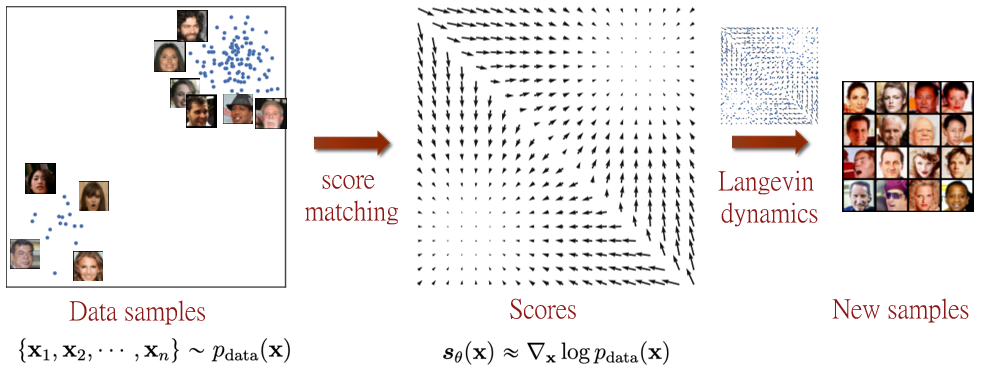

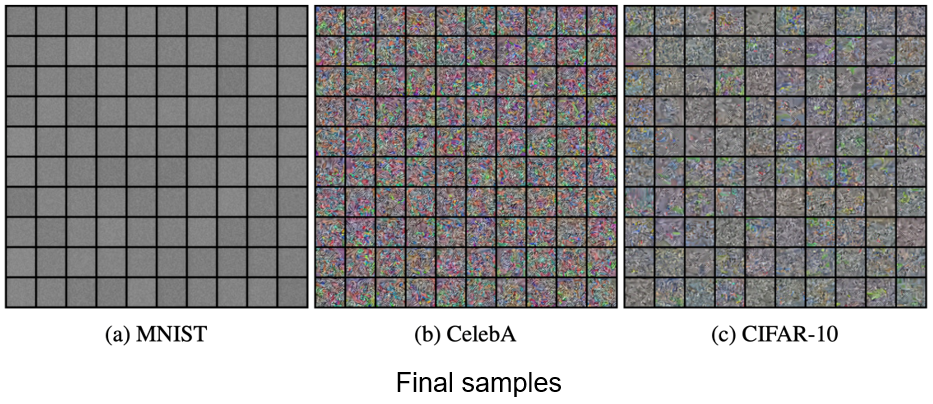

pitfalls
- Manifold hypothesis. Data score is undefined.
- Score matching fails in low data density regions
- Langevin dynamics converges very slowly

#### Multi-scale Noise Perturbation

- The solution to all pitfalls: Gaussian perturbation

trade-off:
- High noise provides useful directional information for Langevin dynamics.
- But perturbed density no longer approximates the true data density.

- In practice, we might want to use multiple scales of noise to perturb the data distribution, and estimate the score of each noise-perturbed distribution.
- The scores of noise perturbed distributions with multiple scales can provide directional information of multiple granularity, and give useful guidance in various distances from the high data density region.

#### Annealed Langevin Dynamics

- Joint scores to samples
- Sample using $\sigma_1 \gt \dots \gt \sigma_L$ sequentially with Langevin dynamics.
  - Anneal down the noise level.
- Samples used as initialization for the next level.

- get the best of both worlds

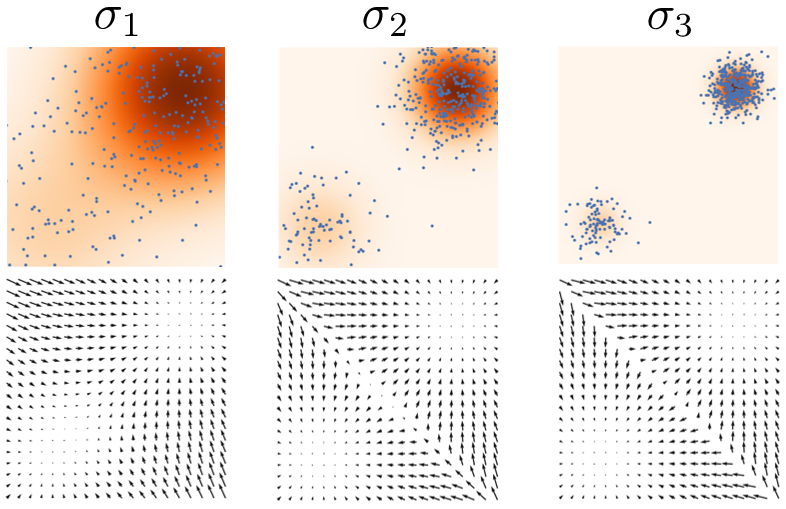

#### Noise Conditional Score Networks (NCSN)

- Joint score estimation

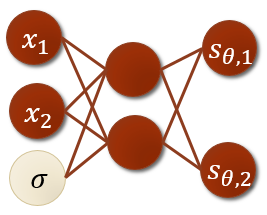

- Denoising score matching is naturally suitable, since the goal is to estimate the score of perturbed data distributions.
- Weighted combination of denoising score matching losses
  - $\begin{align*}
&\quad\ \frac{1}{L}\sum_{i=1}^L \lambda(\sigma_i)\mathbb{E}_{q_{\sigma_1}(x)} \left[ \| \nabla_x \log q_{\sigma_i}(x) - s_\theta(x,\sigma_i) \|_2^2 \right] \\
&=\frac{1}{L}\sum_{i=1}^L \lambda(\sigma_i)\mathbb{E}_{x \sim p_{\text{data}}(x),z \sim \mathcal{N}(0,I)} \left[ \| s_\theta(x+\sigma_i z,\sigma_i)+\frac{z}{\sigma_i} \|_2^2 \right] +\text{const.} \\
&\quad\ (\text{choose} \quad \lambda(\sigma_i)=\sigma_i^2) \\
&=\frac{1}{L}\sum_{i=1}^L \mathbb{E}_{x \sim p_{\text{data}}(x),z \sim \mathcal{N}(0,I)} \left[ \| \sigma_i s_\theta(x+\sigma_i z,\sigma_i)+z \|_2^2 \right] +\text{const.}
\end{align*}$

Training noise conditional score networks:
- Sample a mini-batch of data points $\{x_1,\dots,x_n\} \sim p_{\text{data}}$
- Sample a mini-batch of noise scale indices $\{i_1,\dots,i_n\} \sim \mathcal{U}\{1,\dots,L\}$
- Sample a mini-batch of Gaussian noise $\{z_1,\dots,z_n\} \sim \mathcal{N}(0,I)$
- Estimate the weighted mixture of score matching losses
  - $\frac{1}{n}\sum_{k=1}^n \left[ \| \sigma_{i_k} s_\theta(x_k+\sigma_{i_k} z_k,\sigma_{i_k})+z_k \|_2^2 \right]$
- Stochastic gradient descent

sampling:

<img src="https://github.com/spencer18001/Practical-Deep-Learning/blob/main/annealed_langevin_dynamics.gif?raw=true" height=400px/>

#### Score-Based Generative Modeling via SDEs

perturbing data with stochastic processes (continue-time)
- stochastic differential equation (SDE): $\text{d}x_t=f(x_t,t)\text{d}t+g(t)\text{d}w_t$
  - $f(x_t,t)$: deterministic drift
  - $\text{d}w_t$: infinitesimal noise
  - ordinary differential equation (ODE): $\text{d}x_t=f(x_t,t)\text{d}$
- simple continuous random walk case: $\text{d}x_t=\sigma(t)\text{d}w_t$

<video width="960" height="640" controls>
  <source src="https://github.com/spencer18001/Practical-Deep-Learning/blob/main/forwardSDE.mp4?raw=true" type="video/mp4">
  Your browser does not support the video tag.
</video>

generation via reverse stochastic processes
- $\text{d}x_t=-\sigma(t)^2 \nabla_x \log p_t(x_t) \text{d}t + \sigma(t)\text{d}\bar{w}_t$
  - $\nabla_x \log p_t(x_t)$: score function
  - $\text{d}\bar{w}_t$: infinitesimal noise in the reverse time direction

- controllable generation: use classifier to change the drift

<video width="960" height="640" controls>
  <source src="https://github.com/spencer18001/Practical-Deep-Learning/blob/main/reverseSDE.mp4?raw=true" type="video/mp4">
  Your browser does not support the video tag.
</video>

generative modeling via SDEs
- time-dependent score-based model
  - $s_\theta(x,t) \approx \nabla_x \log p_t(x)$
- training:
  - $\mathbb{E}_{t \in \mathcal{U}(0,T)} \left[ \lambda(t)\mathbb{E}_{p_t(x)} \left[ \| \nabla_x \log p_t(x) - s_\theta(x,t) \|_2^2 \right] \right]$
- reverse-time SDE
  - $\text{d}x_t=-\sigma(t)^2 s_\theta(x,t) \text{d}t + \sigma(t)\text{d}\bar{w}_t$
- Euler-Maruyama (analgous to Euler for ODEs)
  - $x \leftarrow x - \sigma(t)^2 s_\theta(x,t)\Delta t + \sigma(t)z \quad \left( z \sim \mathcal{N}(0,|\Delta t|I) \right)$
  - $t \leftarrow t+ \Delta \quad$ (discretization)
  - the score is the deterministic drift
  - Langevin dynamics/DDPM is a particular type of discretization of the underlying SDE

Predictor-Corrector sampling:
- Predictor: Numerical SDE solver (DDPM)
- Corrector: Score-based MCMC (correct numerical error) (Langevin Dynamic)

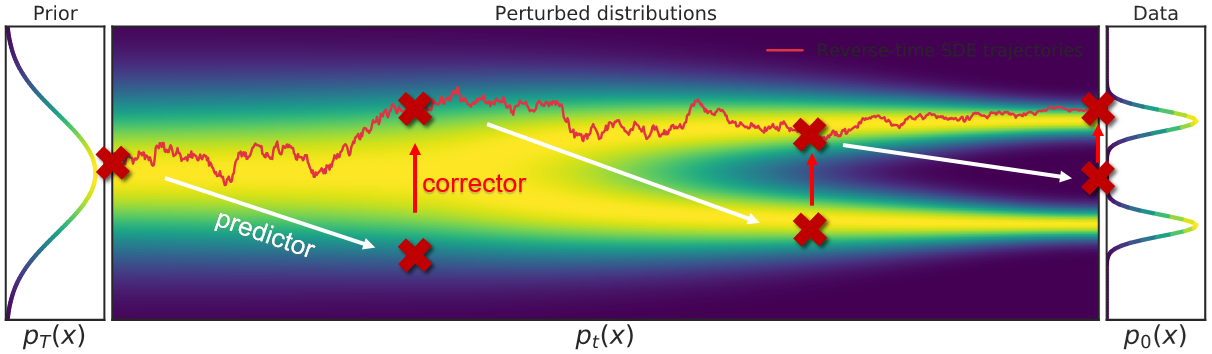

#### Converting the SDE to an ODE

- SDE: $\text{d}x_t=\sigma(t)\text{d}w_t$
    - high quality
- ODE: $\frac{\text{d}x_t}{\text{d}t}=-\frac{1}{2}\sigma(t)^2 \nabla_x \log p_t(x_t)$
    - fast sampling

there is a computation graph where we add randomness at every step and we're defining a somewhat equivalent computation graph where we're putting other randomness in the initial condition

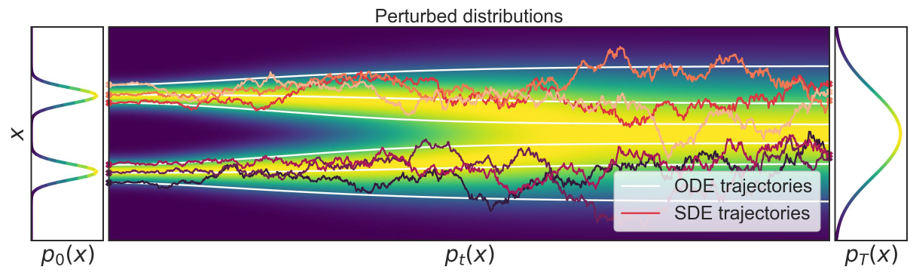

We can think of this as a (continuous time, infinite depth) normalizing flow
- Unique ODE solution $\to$ Invertible mapping
- To invert, solve ODE backwards from $T$ to $0$

- Computing the probability density function (change of variables formula)
  - $\log p_\theta(x_0)=\log \pi(x_T)-\frac{1}{2}\int_0^T\sigma(t)^2 \text{trace} \left( \nabla_x s_\theta(x,t)\text{d}t \right)$

at the inference time you can do
different things at the inference time
you can solve the SDE you can solve the
ODE
but the the scores (learned by score-matching) are the same